# Notebook angle estimation machine learning part
This notebook contains the code that is used to train the model for predicting the best angle at which the angiography should be taken 

In [1]:
import pandas as pd
import torch 
import numpy as np
import torch.nn as nn
from torchsummary import summary
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from datetime import datetime
import neptune
import model as mf

from torchvision.io import read_image
from torchvision.transforms.functional import to_tensor


DATA_PATH = "dataset/" #Do not change folder structure that was created by Kasper
# dataset/
#   DRR_images/
#       [n].png
#   excel/
#       *.xlsx 


In [2]:
run = neptune.init_run(
     name= "Try 3",
     description= "Experiment with new data",
     project="undefined1234/Team-Challenge",
     api_token="eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiJlZTZlZjc1Mi00YTFlLTQ1YjUtYjBiNC02OGRkZTY4ZDAwMTgifQ==",
)  # your credentials

params = {

    "learning_rate": 0.001,
    "momentum": 0.9,
    "optimizer": "Adam"
}
run["parameters"] = params

[neptune] [warning] NeptuneWarning: By default, these monitoring options are disabled in interactive sessions: 'capture_stdout', 'capture_stderr', 'capture_traceback', 'capture_hardware_metrics'. You can set them to 'True' when initializing the run and the monitoring will continue until you call run.stop() or the kernel stops. NOTE: To track the source files, pass their paths to the 'source_code' argument. For help, see: https://docs.neptune.ai/logging/source_code/


[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/undefined1234/Team-Challenge/e/TEAM-7


In [3]:
torch.__version__

'2.6.0+cu126'

In [4]:
torch.cuda.is_available()

True

## Loading labels

In [5]:
labels = pd.read_excel(DATA_PATH+"excel/all_DRR_scores.xlsx")
labels['fullpath'] = DATA_PATH+"DRR_images/"+labels['DRR filename']+".png"
labels['score_classified'] = pd.qcut(labels['score'], 5).factorize()[0]

#labels.iloc[0]['fullpath']
labels

,DRR filename,aneurysm score,neck score,score,fullpath,score_classified
0,C0001_X0_Y0,12.272727,1.783784,14.056511,dataset/DRR_images/C0001_X0_Y0.png,0
1,C0001_X10_Y0,7.358974,1.584906,8.943880,dataset/DRR_images/C0001_X10_Y0.png,1
2,C0001_X20_Y0,5.538462,1.921569,7.460030,dataset/DRR_images/C0001_X20_Y0.png,1
3,C0001_X30_Y0,5.309091,2.074074,7.383165,dataset/DRR_images/C0001_X30_Y0.png,1
4,C0001_X40_Y0,4.949153,1.689189,6.638342,dataset/DRR_images/C0001_X40_Y0.png,2
...,...,...,...,...,...,...
6835,C0074_X310_Y180,2.008721,2.130435,4.139156,dataset/DRR_images/C0074_X310_Y180.png,3
6836,C0074_X320_Y180,1.817175,1.709091,3.526265,dataset/DRR_images/C0074_X320_Y180.png,4
6837,C0074_X330_Y180,1.527578,2.289474,3.817052,dataset/DRR_images/C0074_X330_Y180.png,4
6838,C0074_X340_Y180,3.066038,2.050000,5.116038,dataset/DRR_images/C0074_X340_Y180.png,3


### DataLoader

In [6]:
train, val = train_test_split(labels)

train_dataloader = torch.utils.data.DataLoader(mf.CustomImageDataset(train), batch_size=64, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(mf.CustomImageDataset(val), batch_size=64, shuffle=True)


Feature batch shape: torch.Size([64, 1, 256, 256])
Feature batch type: torch.FloatTensor
Labels batch shape: torch.Size([64])


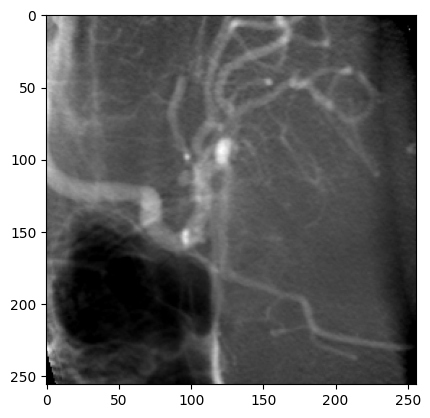

Label: 3


In [9]:
train, label = next(iter(train_dataloader))
print(f"Feature batch shape: {train.size()}")
print(f"Feature batch type: {train.type()}")
print(f"Labels batch shape: {label.size()}")
img = train[31].squeeze()
label = label[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

### Model

In [10]:
device = torch.device("cuda")
model = mf.Block().to(device)

summary(model, torch.Size([1,256,256]), 64)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [64, 4, 256, 256]              40
       BatchNorm2d-2          [64, 4, 256, 256]               8
         MaxPool2d-3          [64, 4, 128, 128]               0
            Conv2d-4         [64, 16, 128, 128]             592
       BatchNorm2d-5         [64, 16, 128, 128]              32
         MaxPool2d-6           [64, 16, 64, 64]               0
           Flatten-7                [64, 65536]               0
            Linear-8                   [64, 64]       4,194,368
              ReLU-9                   [64, 64]               0
           Linear-10                    [64, 5]             325
Total params: 4,195,365
Trainable params: 4,195,365
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 16.00
Forward/backward pass size (MB): 608.06
Params size (MB): 16.00
Est

In [11]:
output = model(train.to(device))
output

tensor([[-8.4173e-01, -8.4977e-01, -4.0036e-02, -8.2388e-01, -1.5778e-01],
        [ 6.4813e-02, -2.8074e-01, -1.9351e-01, -2.7797e-02, -7.9866e-02],
        [-1.4850e-01, -1.9002e-01, -1.8426e-01, -4.7615e-01,  4.6731e-02],
        [ 1.6255e-01, -3.4518e-01, -1.1145e-01, -1.4943e-01, -5.8064e-02],
        [ 1.0936e-01, -1.9179e-01, -1.3327e-01, -1.4309e-01, -1.5931e-01],
        [-4.9673e-02, -5.0597e-01,  6.0744e-04, -3.9886e-01, -9.9027e-02],
        [ 1.3818e-01, -2.1407e-01, -1.2383e-01, -9.6363e-02, -1.6381e-01],
        [-2.5164e-01, -4.3258e-01, -3.4188e-01, -1.2984e+00,  2.7893e-01],
        [-3.0594e-01, -2.7598e-01, -5.9641e-02, -5.5490e-01,  1.1510e-01],
        [-1.3508e-01, -3.5880e-01, -6.6085e-02, -4.1683e-01, -1.3691e-01],
        [-4.2988e-01, -4.0180e-01, -8.3127e-02, -6.5427e-01, -1.0399e-02],
        [ 7.8808e-02, -2.8027e-01, -1.2132e-01, -2.0029e-01, -1.9552e-01],
        [-1.6858e-02, -9.4847e-02, -2.7410e-01, -1.7873e-01, -8.5560e-02],
        [ 5.6131e-03, -1.

### Loss function

In [12]:
loss_fn = nn.CrossEntropyLoss()
loss_fn.to(device=device)

CrossEntropyLoss()

### Optimizer

In [13]:
optimizer = torch.optim.Adam(model.parameters(), lr=params["learning_rate"])


### Training

In [14]:
def train_one_epoch(epoch_index):
    running_loss = 0.
    last_loss = 0.

    # Here, we use enumerate(training_loader) instead of
    # iter(training_loader) so that we can track the batch
    # index and do some intra-epoch reporting
    for i, data in enumerate(train_dataloader):
        # Every data instance is an input + label pair
        inputs, labels = data
        

        # Zero your gradients for every batch!
        optimizer.zero_grad()

        # Make predictions for this batch
        outputs = model(inputs.to(device))

        # Compute the loss and its gradients
        loss = loss_fn(outputs, labels.to(device))
        loss.backward()

        # Adjust learning weights
        optimizer.step()

        # Gather data and report
        running_loss += loss.item()
        if i % 10 == 9:
            last_loss = running_loss / 10 # loss per batch
            print('  batch {} loss: {}'.format(i + 1, last_loss))
            tb_x = epoch_index * len(train_dataloader) + i + 1
            running_loss = 0.

    return last_loss

In [15]:
# Initializing in a separate cell so we can easily add more epochs to the same run
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
#writer = SummaryWriter('runs/fashion_trainer_{}'.format(timestamp))
epoch_number = 0






EPOCHS = 100

best_vloss = 1_000_000.

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch(epoch_number)


    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_dataloader):
            vinputs, vlabels = vdata
            voutputs = model(vinputs.to(device))
            vloss = loss_fn(voutputs, vlabels.to(device))
            running_vloss += vloss

    avg_vloss = running_vloss / (i + 1)
    print('LOSS train {} valid {}'.format(avg_loss, avg_vloss))
    run["train/loss"].append(avg_loss)
    run["val/loss"].append(avg_vloss)



    # Track best performance, and save the model's state
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = 'model_{}_{}'.format(timestamp, epoch_number)
        torch.save(model.state_dict(), model_path)

    epoch_number += 1
model.train(False)
run.stop()

EPOCH 1:
  batch 10 loss: 9.986700749397277
  batch 20 loss: 3.719015884399414
  batch 30 loss: 1.8497026801109313
  batch 40 loss: 1.7049474358558654
  batch 50 loss: 1.6451820492744447
  batch 60 loss: 1.6152716636657716
  batch 70 loss: 1.595125102996826
  batch 80 loss: 1.6293087482452393
LOSS train 1.6293087482452393 valid 1.601688265800476
EPOCH 2:
  batch 10 loss: 1.5894396901130676
  batch 20 loss: 1.5836158394813538
  batch 30 loss: 1.5616112232208252
  batch 40 loss: 1.5736982822418213
  batch 50 loss: 1.5893513560295105
  batch 60 loss: 1.586881148815155
  batch 70 loss: 1.5912255764007568
  batch 80 loss: 1.5981208682060242
LOSS train 1.5981208682060242 valid 1.5869725942611694
EPOCH 3:
  batch 10 loss: 1.5701090812683105
  batch 20 loss: 1.5767693519592285
  batch 30 loss: 1.5508747100830078
  batch 40 loss: 1.5478996872901916
  batch 50 loss: 1.5655018091201782
  batch 60 loss: 1.5605454206466676
  batch 70 loss: 1.567337167263031
  batch 80 loss: 1.5388687610626222
LOSS 

In [16]:
torch.save(model.state_dict(), "mymodel_classified.pth")

In [17]:
torch.cuda.empty_cache()
del model
del loss_fn

print(torch.cuda.memory_allocated())
print(torch.cuda.memory_reserved())

470085120
513802240
